# Support Vector Regression (SVR)

## Problem Statement

In this notebook, we will implement Support Vector Regression using Python.

SVR is used to predict continuous numerical values.  
It tries to find the best boundary that fits the data with minimum error.

## Dataset Used

We will use the Tips Dataset from Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Loading

Now we will load the Tips dataset and convert it into a Pandas DataFrame.

In [2]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Exploratory Data Analysis (EDA)

In this step, we will check:

- Dataset shape
- Missing values
- Data types
- Statistical summary
- Correlation analysis
- Visualization

In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

df.describe()

Dataset Shape: (244, 7)

Missing Values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Data Types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [4]:
df.select_dtypes(include=["int64", "float64"]).corr()

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


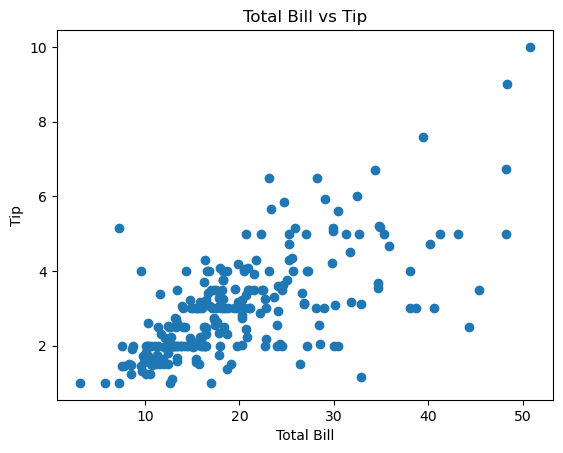

In [5]:
plt.scatter(df["total_bill"], df["tip"])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Total Bill vs Tip")
plt.show()

## Data Preprocessing

In this dataset:

- There are no missing values
- Some columns are categorical
- SVR works better when features are scaled

We will encode categorical columns and scale the data.

In [6]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,total_bill,tip,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,1.01,2,True,True,False,False,True,True
1,10.34,1.66,3,False,True,False,False,True,True
2,21.01,3.50,3,False,True,False,False,True,True
3,23.68,3.31,2,False,True,False,False,True,True
4,24.59,3.61,4,True,True,False,False,True,True


In [7]:
X = df.drop("tip", axis=1)
y = df["tip"]

X.head()

,total_bill,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,2,True,True,False,False,True,True
1,10.34,3,False,True,False,False,True,True
2,21.01,3,False,True,False,False,True,True
3,23.68,2,False,True,False,False,True,True
4,24.59,4,True,True,False,False,True,True


## Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (195, 8)
Testing Data: (49, 8)


## Feature Scaling

SVR is distance-based, so feature scaling is very important.

We will apply StandardScaler to input features.

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building

Now we will create the Support Vector Regression model.

We will use the RBF kernel because it works well for non-linear data.

In [11]:
svr_model = SVR(kernel="rbf")

## Model Training

Now we will train the SVR model using training data.

In [12]:
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## Model Prediction

Now we will predict tip values using testing data.

In [13]:
y_pred = svr_model.predict(X_test_scaled)

y_pred[:10]

array([3.07378371, 2.03972352, 3.96464743, 2.9744753 , 2.1858982 ,
       3.60766309, 3.79367667, 1.92194367, 2.45998111, 2.8568579 ])

## Model Evaluation

We will evaluate the model using:

- MAE
- MSE
- RMSE
- R² Score

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.6852531751777438
MSE: 0.7853545028982103
RMSE: 0.8862022923115299
R2 Score: 0.3717019947150799


## Result Interpretation

Support Vector Regression predicts continuous values using support vectors.

A lower RMSE means fewer prediction errors.  
A higher R² score means the model explains the target values better.

In [15]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
24,3.18,3.073784
6,2.00,2.039724
153,2.00,3.964647
211,5.16,2.974475
198,2.00,2.185898
176,2.00,3.607663
192,2.56,3.793677
124,2.52,1.921944
9,3.23,2.459981
101,3.00,2.856858


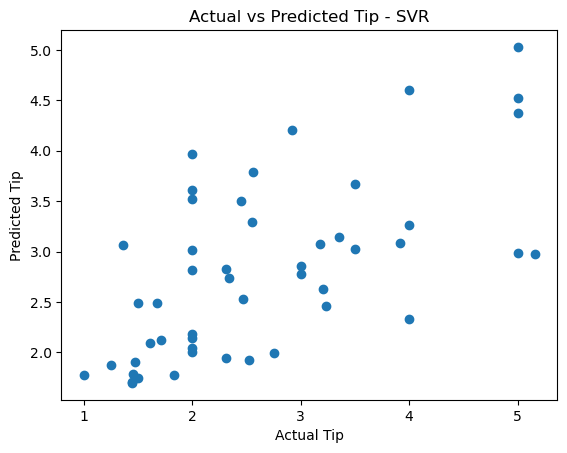

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tip - SVR")
plt.show()

## Conclusion

In this notebook, we successfully implemented Support Vector Regression using Python.

We performed:

- Dataset loading
- Exploratory Data Analysis
- Data preprocessing
- Feature scaling
- Train-test split
- Model building
- Model training
- Model prediction
- Model evaluation
- Result interpretation

SVR is useful for predicting continuous values and works well when proper feature scaling is applied.